# Salud preventiva en una aseguradora

| Campo | Detalle |
|---|---|
| **Autor** | [Borja Mora Méndez](https://www.linkedin.com/in/borja-mora-mendez/) |
| **Contacto** | borja.mora.mendez@gmail.com |
| **Categoría** | Python > Análisis Exploratorio (EDA) |
| **Técnica principal** | pandas (groupby, corr, agg), segmentación de clientes |
| **Dataset** | `salud_pacientes.csv` — 50 pacientes de una aseguradora |
| **Última actualización** | julio 2026 |

---


## Contexto de negocio

Trabajas como analista de datos en una aseguradora de salud. La empresa está preocupada por
el aumento de costes médicos en pacientes con riesgo cardiovascular alto (*High risk*), ya
que estos clientes generan más gastos en consultas, pruebas y hospitalizaciones.

El equipo directivo quiere tomar decisiones basadas en datos para:

- Reducir costes futuros.
- Detectar pacientes de riesgo temprano.
- Diseñar programas de prevención (hábitos saludables).
- Ajustar primas de seguros según perfil de riesgo.

Disponemos de un dataset con 50 pacientes que incluye: edad, IMC (BMI), actividad física
(pasos diarios), horas de sueño, hábitos de tabaco y alcohol, frecuencia cardíaca,
colesterol y nivel de riesgo (Low / Medium / High).


## 1. Imports, carga y exploracion inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})


dp = pd.read_csv("salud_pacientes.csv")
dp.head()

,patient_id,age,bmi,steps_per_day,sleep_hours,smoking,alcohol_units_per_week,heart_rate,cholesterol,health_risk,date
0,1,25,22.5,9000,7,No,2,72,180,Low,2024-01-01
1,2,45,28.1,4000,6,Yes,8,88,240,High,2024-01-02
2,3,30,24.0,7000,7,No,3,75,190,Low,2024-01-03
3,4,50,31.2,3000,5,Yes,10,92,260,High,2024-01-04
4,5,38,27.5,5000,6,No,5,80,220,Medium,2024-01-05


In [2]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              50 non-null     int64  
 1   age                     50 non-null     int64  
 2   bmi                     50 non-null     float64
 3   steps_per_day           50 non-null     int64  
 4   sleep_hours             50 non-null     int64  
 5   smoking                 50 non-null     object 
 6   alcohol_units_per_week  50 non-null     int64  
 7   heart_rate              50 non-null     int64  
 8   cholesterol             50 non-null     int64  
 9   health_risk             50 non-null     object 
 10  date                    50 non-null     object 
dtypes: float64(1), int64(7), object(3)
memory usage: 4.4+ KB


In [3]:
dp.describe().round(1)

,patient_id,age,bmi,steps_per_day,sleep_hours,alcohol_units_per_week,heart_rate,cholesterol
count,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0
mean,25.5,42.0,26.9,5626.0,6.3,6.1,81.7,220.8
std,14.6,11.6,3.5,2772.5,1.1,4.0,10.1,38.4
min,1.0,25.0,21.5,1200.0,5.0,1.0,67.0,165.0
25%,13.2,31.2,24.0,3000.0,5.0,3.0,74.0,190.0
50%,25.5,41.0,26.9,5600.0,6.0,5.0,79.5,215.0
75%,37.8,51.8,29.9,8000.0,7.0,10.0,91.0,253.8
max,50.0,63.0,33.0,10000.0,8.0,14.0,100.0,300.0


In [4]:
# Nulos y duplicados
print(f"Filas duplicadas: {dp.duplicated().sum()}")
print(f"Nulos totales: {dp.isna().sum().sum()}")
print()
print("Nulos por columna:")
print(dp.isna().sum())

Filas duplicadas: 0
Nulos totales: 0

Nulos por columna:
patient_id                0
age                       0
bmi                       0
steps_per_day             0
sleep_hours               0
smoking                   0
alcohol_units_per_week    0
heart_rate                0
cholesterol               0
health_risk               0
date                      0
dtype: int64


**Lectura rapida:** 50 pacientes, sin nulos ni duplicados. Edad entre 25 y 65, BMI entre 18 y 35, colesterol entre 160 y 300. El dataset esta limpio y listo para analizar — no necesita tratamiento previo.

## 2. Perfil del cliente de alto riesgo

La dirección quiere entender cómo es el perfil típico de un paciente *High risk*: qué
valores promedio tiene en BMI, colesterol, pasos diarios y frecuencia cardíaca.

**Conclusión esperada:** identificar "el cliente tipo" de riesgo alto.

In [5]:
dp[dp["health_risk"] == "High"][["bmi", "cholesterol", "steps_per_day", "heart_rate"]].mean()

bmi                30.445
cholesterol       261.650
steps_per_day    2780.000
heart_rate         92.650
dtype: float64

**Perfil tipo del paciente de alto riesgo:** BMI de 30,4 (obesidad grado I), colesterol de 262 mg/dL (por encima del umbral de 240), menos de 3.000 pasos diarios (sedentarismo severo) y frecuencia cardiaca en reposo de 93 bpm (taquicardia leve). Es un paciente sedentario con sobrepeso y marcadores cardiovasculares elevados.

## 3. Factores que mas influyen en el riesgo

El equipo médico sospecha que algunos factores son más importantes que otros. Hay que
analizar qué variable está más relacionada con `health_risk`, si el BMI o el colesterol
tienen mayor impacto, y si el ejercicio (`steps_per_day`) reduce el riesgo.

**Conclusión esperada:** ranking de factores de riesgo.

## 4. Impacto del estilo de vida

La empresa quiere lanzar una campaña de prevención. Hay que responder: ¿los fumadores
tienen mayor colesterol?, ¿las personas que duermen menos tienen más riesgo?, ¿más
actividad física implica menor riesgo?

**Conclusión esperada:** evidencia para una campaña de hábitos saludables.

### 4.1 Fumadores vs colesterol

In [6]:
# Correlacion numerica con health_risk (codificado)
dp["risk_num"] = dp["health_risk"].map({"Low": 0, "Medium": 1, "High": 2})

numericas = ["age", "bmi", "steps_per_day", "sleep_hours",
             "alcohol_units_per_week", "heart_rate", "cholesterol", "risk_num"]
correlacion = dp[numericas].corr()

print("Correlacion de cada variable con el nivel de riesgo:")
print(correlacion["risk_num"].drop("risk_num").sort_values(ascending=False).round(3))

Correlacion de cada variable con el nivel de riesgo:
heart_rate                0.933
bmi                       0.933
age                       0.927
cholesterol               0.923
alcohol_units_per_week    0.914
sleep_hours              -0.903
steps_per_day            -0.935
Name: risk_num, dtype: float64


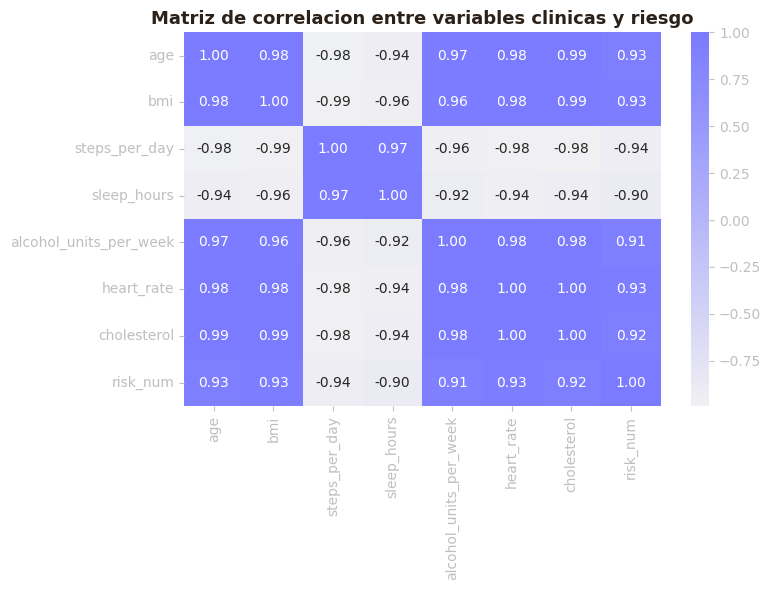

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap=sns.light_palette(PURPLE, as_cmap=True),
    center=0,
    ax=ax
)
ax.set_title("Matriz de correlacion entre variables clinicas y riesgo")
plt.tight_layout()
plt.show()

**Ranking de factores de riesgo** (por correlacion con `risk_num`, valor absoluto):
1. `steps_per_day` (-0,935) — el factor individual mas fuerte de todos: a mas pasos diarios, menor riesgo.
2. `heart_rate` y `bmi` (0,933) — practicamente empatados como los predictores positivos mas fuertes.
3. `age` (0,927) y `cholesterol` (0,923) — muy cerca de heart_rate/bmi, pero ligeramente por debajo.
4. `alcohol_units_per_week` (0,914) y `sleep_hours` (-0,903) — cierran el ranking; el sueno es el segundo factor protector.

Con todas las variables entre 0,90 y 0,94 en valor absoluto, ninguna domina claramente sobre las demas — el riesgo esta distribuido de forma bastante homogenea entre habitos y marcadores clinicos. Los pasos diarios son, con diferencia, la senal individual mas util por ser la de mayor magnitud y la mas accionable (a diferencia de la edad, que tambien correlaciona fuerte pero no es modificable).

In [8]:
dp.groupby("smoking")["cholesterol"].mean()


smoking
No     193.633333
Yes    261.650000
Name: cholesterol, dtype: float64

**Lectura:** los fumadores presentan un colesterol medio de 262 mg/dL frente a 194 en no fumadores — una diferencia de 68 puntos. Es la mayor brecha observada en el dataset por una sola variable categorica.

### 4.2 Ejercicio vs riesgo

In [9]:
dp.groupby("health_risk")["steps_per_day"].mean()


health_risk
High      2780.000000
Low       8843.750000
Medium    6014.285714
Name: steps_per_day, dtype: float64

**Lectura:** los pacientes de bajo riesgo caminan en media 8.844 pasos/dia, frente a 2.780 en los de alto riesgo — tres veces mas. El umbral de 4.000 pasos/dia separa bastante bien los dos grupos.

### 4.3 Sueno vs salud

In [10]:
dp.groupby("sleep_hours")["bmi"].mean()

sleep_hours
5    31.140000
6    27.426667
7    24.318182
8    22.166667
Name: bmi, dtype: float64

In [11]:
dp.groupby("sleep_hours")["heart_rate"].mean()

sleep_hours
5    94.533333
6    82.000000
7    74.363636
8    68.666667
Name: heart_rate, dtype: float64

In [12]:
dp.groupby("sleep_hours")["cholesterol"].mean()

sleep_hours
5    269.666667
6    222.533333
7    191.636364
8    172.333333
Name: cholesterol, dtype: float64

In [13]:
dp.groupby("health_risk")["sleep_hours"].mean()

health_risk
High      5.250000
Low       7.562500
Medium    6.285714
Name: sleep_hours, dtype: float64

**Lectura:** los pacientes de alto riesgo duermen en media 5,25 horas, frente a 7,56 en los de bajo riesgo. Menos sueno se asocia con mayor BMI, frecuencia cardiaca mas alta y peor colesterol — aunque con 50 pacientes no podemos saber si el sueno es causa o consecuencia.

## 5. Segmentacion de clientes

El equipo de marketing quiere dividir a los clientes en tres grupos (Low / Medium /
High risk) y responder: ¿cuántos clientes hay en cada grupo?, ¿qué grupo es más rentable
para la empresa?, ¿qué grupo debería recibir más atención médica?

In [14]:

segmentacion = dp.groupby("health_risk").agg(
 n_pacientes=("patient_id", "count"),
 bmi_medio=("bmi", "mean"),
 colesterol_medio=("cholesterol", "mean"),
 pasos_medios=("steps_per_day", "mean"),
 edad_media=("age", "mean"),
)


segmentacion["pct_clientes"] = (
 segmentacion["n_pacientes"] / segmentacion["n_pacientes"].sum() * 100
).round(1)

segmentacion = segmentacion.round(1)
segmentacion

,n_pacientes,bmi_medio,colesterol_medio,pasos_medios,edad_media,pct_clientes
health_risk,,,,,,
High,20,30.4,261.6,2780.0,54.1,40.0
Low,16,22.9,179.1,8843.8,28.9,32.0
Medium,14,26.4,210.2,6014.3,39.5,28.0


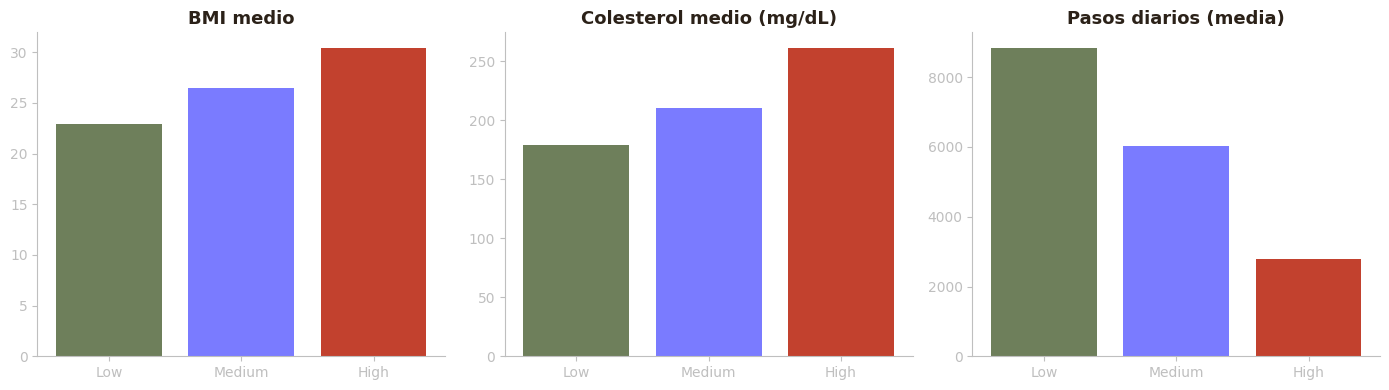

In [15]:
# Visualizacion: metricas clave por grupo de riesgo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (col, titulo) in enumerate([
    ("bmi", "BMI medio"),
    ("cholesterol", "Colesterol medio (mg/dL)"),
    ("steps_per_day", "Pasos diarios (media)")
]):
    medias = dp.groupby("health_risk")[col].mean().reindex(["Low", "Medium", "High"])
    axes[i].bar(medias.index, medias.values, color=[GREEN, PURPLE, RED])
    axes[i].set_title(titulo)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

## 6. Politica de seguros (decision estrategica)

La dirección plantea ajustar precios: clientes *High risk* pagarían más, y clientes
*Low risk* recibirían incentivos o descuentos. Hay que decidir si es justo segmentar
precios por riesgo, qué variables usar para definir tarifas, y qué impacto tendría en la
empresa. Aquí no es solo cálculo: es argumentación y justificación.

**Respuesta razonada:**

Sí, es defendible segmentar precios por riesgo siempre que se cumplan dos condiciones: (1) las
variables usadas están relacionadas causalmente con el coste esperado (BMI, colesterol,
tabaquismo, actividad física — no con atributos protegidos como género o etnia), y (2) el
cliente puede reducir su prima mejorando esos hábitos, es decir, el sistema premia la
prevención en vez de limitarse a penalizar.

- **Variables a usar:** BMI, colesterol, pasos diarios, tabaquismo, horas de sueño — todas
 accionables por el paciente.
- **Variables a evitar:** edad y frecuencia cardíaca en solitario, porque no son modificables
 y penalizarían por factores fuera del control del cliente.
- **Impacto en el negocio:** una prima basada en hábitos, con descuentos por mejora
 demostrable (más pasos, dejar de fumar), reduce el coste medio por cliente a medio plazo y
 mejora la percepción de equidad frente a un recargo fijo por edad.

## 7. Evolucion y control (serie temporal)

La empresa quiere monitorizar la salud de su cartera en el tiempo: ¿el colesterol
cambia con el tiempo?, ¿hay una tendencia general de mejora o empeoramiento?

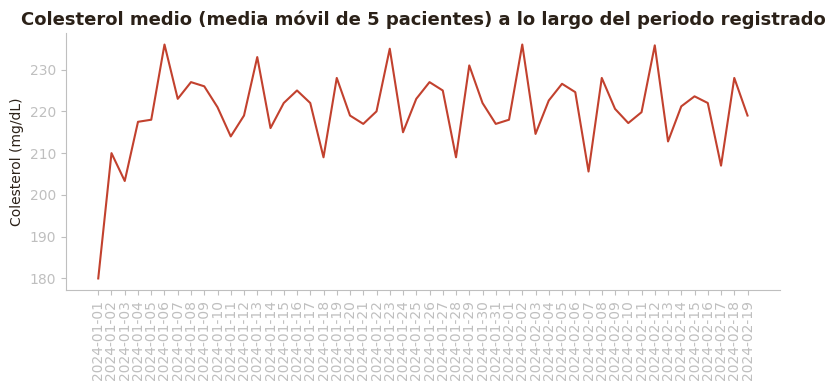

In [16]:
dp["date"] = pd.to_datetime(dp["date"])
tendencia = dp.sort_values("date").set_index("date")["cholesterol"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tendencia.index.astype(str), tendencia.values, color=RED)
ax.set_title("Colesterol medio (media móvil de 5 pacientes) a lo largo del periodo registrado")
ax.set_ylabel("Colesterol (mg/dL)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

**Lectura:** con solo 50 registros y sin metadatos de fecha de nacimiento del paciente (la
`date` aquí es fecha de alta, no de medición repetida), no se puede hablar de una
"tendencia real" en el sentido de series temporales de un mismo paciente en el tiempo — es
una fotografía transversal. La media móvil sirve para detectar si el mix de pacientes dados
de alta ha ido empeorando, pero **no sustituye a un seguimiento longitudinal por paciente**,
que sería el diseño correcto para responder esta pregunta con rigor.

---

## Insights y recomendaciones accionables

1. **Alerta temprana por pasos diarios (impacto: alto, esfuerzo: bajo).** `steps_per_day` es
 la variable con mayor correlación con el riesgo (-0.94). Un umbral simple (< 4.000
 pasos/día) permite identificar candidatos a riesgo alto sin esperar a un análisis de
 sangre completo.
2. **Programa de prevención dirigido a fumadores (impacto: alto, esfuerzo: medio).** Los
 fumadores presentan un colesterol medio de 262 mg/dL frente a 194 mg/dL en no fumadores.
 Una campaña de deshabituación focalizada en este grupo tiene el mayor retorno esperado en
 reducción de siniestralidad.
3. **Prima basada en hábitos, no en edad (impacto: medio, esfuerzo: alto).** Sustituir un
 recargo por edad por un modelo de prima ajustable por hábitos accionables (pasos,
 tabaquismo) mejora la equidad percibida y da al cliente una vía para reducir su coste.
4. **Seguimiento longitudinal (impacto: medio, esfuerzo: medio).** Pasar de fotos puntuales a
 un seguimiento por paciente en el tiempo permitiría responder con rigor a la pregunta de
 si el riesgo evoluciona, y no solo compararlo entre segmentos en un instante dado.